# !This notebook is still under construction!

# Quantifying intertexts: textual overlap

There are many ways of calculating the textual overlap between two texts. Three of them are explored in this notebook, all based on the verse counts of the texts, as well as the shared verses between two works.

**Jaccard Similarity**: Calculating the Jaccard similarity is a way of measuring the overlap between two texts numerically. Given two sets, A and B, the Jaccard Similarity is defined as the size of the intersection of set A and set B (i.e. the number of common elements) over the size of the union of set A and set B (i.e. the number of unique elements). The Jaccard distance is bounded between 0 and 1, with 1 representing identical texts and 0 unique ones. The Jaccard similarity does not take into consideration different lengths of two texts. Naturally, if a text of 2000 verses gets compared to one of 200, and one of also 2000, and both combinations share 100 verses, this is much more meaningful for the short one. The jaccard distance however does not account for this.

**Szymkiewicz–Simpson coefficient** (overlap coefficient): This is defined as the size of the union of set A and set B over the size of the smaller set between A and B. It takes into account more the wieght of overlap in smaller texts.

**Sørensen–Dice coefficient**: This one checks to which extent a smaller text is present in a larger one.

https://developer.nvidia.com/blog/similarity-in-graphs-jaccard-versus-the-overlap-coefficient/


In [1]:
## kan segmentatie ons helpen?

## Loading in the libraries

In [2]:
import pandas as pd
from tqdm import tqdm
import lxml.etree

## Loading in and merging the data

In [3]:
meta_df = pd.read_excel('../data/metadata_corrected.xlsx')
meta_df = meta_df[meta_df['genre'] == 'Epiek']
meta_df = meta_df[meta_df['exclude'] != 'x']
meta_df.sample(10)

,id,title,author,provenance,date_range,genre,subgenre,exclude
3,anatomie_van_de_mens,Anatomie van de mens,NaN,cdrom-mnl,1350-1400,Epiek,Didactiek,NaN
175,roman_van_den_riddere_metter_mouwen,Riddere metter mouwen,NaN,cdrom-mnl,1300-1350,Epiek,Arthur,NaN
181,roelantslied_fragm_br,Roelantslied,NaN,cdrom-mnl,1350-1400,Epiek,Karel,NaN
202,sint_servaes,Sint Servaes legende,Hendrik van Veldeke,cdrom-mnl,1450-1500,Epiek,Heiligenleven,NaN
52,die_dietsche_lucidarius,Dietsche Lucidarius,NaN,cdrom-mnl,1400-1420,Epiek,Didactiek,NaN
246,Tristant,Tristant,NaN,CG1,1250-1250,Epiek,Arthur,NaN
150,ogier_van_denemarken_fragm_l,Ogier van Denemarken,NaN,cdrom-mnl,1300-1400,Epiek,Karel,NaN
258,van_den_vijf_vrouden,Van den vijf vrouden,NaN,cdrom-mnl,1339-1339,Epiek,Didactiek,NaN
107,lantsloot_van_der_haghedochte,Lantsloot van der Haghedochte,NaN,cdrom-mnl,1300-1350,Epiek,Arthur,NaN
183,roelantslied_fragm_ro,Roelantslied,NaN,cdrom-mnl,1350-1400,Epiek,Karel,NaN


In [4]:
def load_verses(filepath, rm_interpol=True):    
    tree = lxml.etree.parse(filepath)
    
    if rm_interpol:
        for interpolation in tree.xpath("//interpolation"):
            interpolation.getparent().remove(interpolation)
    
    verses = []
    
    for line_node in tree.iterfind('//l'):
        verse = []
        
        lemma_tags = [l.text if l.text else "" for l in line_node.iterfind('.//lemma')]
        pos_tags = [p.text if p.text else "" for p in line_node.iterfind('.//pos')]
        
        for lemma, pos in zip(lemma_tags, pos_tags):
            lemma = lemma or ""  # Ensure lemma is not None
            pos = pos or ""      # Ensure pos is not None
            
            for l, p in zip(lemma.split('+'), pos.split('+')):
                if p == 'NOU-P':
                    verse.append(('NOU-P', 'NOU-P'))
                else:
                    verse.append((l, p))
        
        verses.append(verse)
    
    return verses

In [5]:
works = []
rm_interpol = True

pbar = tqdm(meta_df.groupby('title'), desc='description')
for title, group in pbar:
    pbar.set_description('{message: <{width}}'.format(message=title[:50], width=50))
    meta = list(group.sample(1)[['title', 'author', 'genre', 'subgenre']].values[0])
    words = []

    for id_ in sorted(group['id']):
        try:
            words.extend(load_verses(f'../data/xml_galahad_BY-split/{id_}.xml', rm_interpol=rm_interpol))
        except OSError:
            print(f'- Could not load {id_}')
            continue

    verse_count = len(words)  # Count verses for this work
    works.append(meta + [words, verse_count])

# Create DataFrame with verse counts
work_df = pd.DataFrame(works, columns=['title', 'author', 'genre', 'subgenre', 'text', 'verse_count'])
work_df

Wrake van Ragisel                                 : 100%|█| 164/164 [00:09<00:00


,title,author,genre,subgenre,text,verse_count
0,Alexanders geesten,Jacob van Maerlant,Epiek,Ridder,"[[(het, PD(type=pers,position=free)), (zijn, V...",14218
1,Alexiuslegende,NaN,Epiek,Heiligenleven,"[[(node, ADV(type=reg)), (ik, PD(type=pers,pos...",54
2,Anatomie van de mens,NaN,Epiek,Didactiek,"[[(willen, VRB(finiteness=fin,tense=pres)), (g...",181
3,Arturs doet,NaN,Epiek,Arthur,"[[(men, PD(type=pers,position=free)), (zeggen,...",13025
4,Aubri de Borgengoen,NaN,Epiek,Karel,"[[(mijn, PD(type=poss,position=prenom)), (goed...",346
...,...,...,...,...,...,...
159,Walewein (Penninc),Penninc,Epiek,Arthur,"[[(van, ADP(type=pre)), (de, PD(type=d-p,subty...",7653
160,Walewein (Vostaert),Pieter Vostaert,Epiek,Arthur,"[[(nu, ADV(type=reg)), (horten, VRB(finiteness...",3527
161,Walewein ende Keye,NaN,Epiek,Arthur,"[[(die, PD(type=d-p,subtype=art,position=preno...",3668
162,Willem van Oringen,NaN,Epiek,Karel,"[[(met, ADP(type=pre)), (zijn, PD(type=poss,po...",325


In [6]:
par = pd.read_excel('../data/parallel_counts_exhaustive.xlsx')
par.sample(10)

,work1,work2,parallel_count_below_threshold
21391,Van ghevene,Wrake van Ragisel,0
7251,Der minnen loep,Queeste van den Grale,79
16353,Merlijns boec,Van den neghen besten (lang),0
19431,Roman van Cassamus (kort),Van ons heren wonden,0
20595,Spiegel historiael (P2),Van Maskeroen,43
19869,Segheliin van Jerusalem,Walewein (Penninc),212
5006,Brabantsche yeesten (B6),Slag van Crecy,11
4336,Brabantsche yeesten (B1-3),Der leken spieghel,420
19195,Roman der Lorreinen II,Sinte Franciscus leven,59
1066,Arturs doet,Drie daghe here,2


In [7]:
# Filter out rows where either work1 or work2 is not in work_df['title']
valid_titles = set(work_df['title'])
par = par[par['work1'].isin(valid_titles) & par['work2'].isin(valid_titles)].copy()

# Check if all titles in par['work1'] exist in work_df['title']
missing_in_work_df_1 = par[~par['work1'].isin(work_df['title'])]['work1'].unique()
missing_in_work_df_2 = par[~par['work2'].isin(work_df['title'])]['work2'].unique()

if len(missing_in_work_df_1) == 0 and len(missing_in_work_df_2) == 0:
    print("All titles in 'par' match titles in 'work_df'. No mismatches.")
else:
    print("Some titles in 'par' do not match titles in 'work_df':")
    if len(missing_in_work_df_1) > 0:
        print("\nTitles from 'work1' not in work_df['title']:")
        for title in missing_in_work_df_1:
            print("-", title)
    if len(missing_in_work_df_2) > 0:
        print("\nTitles from 'work2' not in work_df['title']:")
        for title in missing_in_work_df_2:
            print("-", title)

# Merge metadata for work1
par = par.merge(
    work_df.rename(columns={
        'title': 'work1',
        'author': 'author_t1',
        'subgenre': 'subgenre_t1',
        'verse_count': 'verse_count_t1'
    })[['work1', 'author_t1', 'subgenre_t1', 'verse_count_t1']],
    on='work1',
    how='left'
)

# Merge metadata for work2
par = par.merge(
    work_df.rename(columns={
        'title': 'work2',
        'author': 'author_t2',
        'subgenre': 'subgenre_t2',
        'verse_count': 'verse_count_t2'
    })[['work2', 'author_t2', 'subgenre_t2', 'verse_count_t2']],
    on='work2',
    how='left'
)

# Rename and reorder columns
par = par.rename(columns={'work1': 't1', 'work2': 't2', 'parallel_count_below_threshold':'parallel_verses'})

column_order = [
    't1', 't2', 'parallel_verses',
    'author_t1', 'author_t2',
    'subgenre_t1', 'subgenre_t2',
    'verse_count_t1', 'verse_count_t2'
]

par = par[[col for col in column_order if col in par.columns]]
par

All titles in 'par' match titles in 'work_df'. No mismatches.


,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2
0,Alexanders geesten,Alexiuslegende,1,Jacob van Maerlant,NaN,Ridder,Heiligenleven,14218,54
1,Alexanders geesten,Anatomie van de mens,4,Jacob van Maerlant,NaN,Ridder,Didactiek,14218,181
2,Alexanders geesten,Arturs doet,312,Jacob van Maerlant,NaN,Ridder,Arthur,14218,13025
3,Alexanders geesten,Aubri de Borgengoen,10,Jacob van Maerlant,NaN,Ridder,Karel,14218,346
4,Alexanders geesten,Barlaam en Josaphat,7,Jacob van Maerlant,NaN,Ridder,Ridder,14218,178
...,...,...,...,...,...,...,...,...,...
13361,Walewein (Vostaert),Willem van Oringen,7,Pieter Vostaert,NaN,Arthur,Karel,3527,325
13362,Walewein (Vostaert),Wrake van Ragisel,46,Pieter Vostaert,NaN,Arthur,Arthur,3527,4216
13363,Walewein ende Keye,Willem van Oringen,2,NaN,NaN,Arthur,Karel,3668,325
13364,Walewein ende Keye,Wrake van Ragisel,226,NaN,NaN,Arthur,Arthur,3668,4216


## Apply the similarity measures

### Jaccard Similarity

In [8]:
def jaccard (df):
    df['union'] = df['verse_count_t1'] + df['verse_count_t2'] - df['parallel_verses']
    df['jaccard'] =  df['parallel_verses'] / df['union']
    df['jaccard'] = df['jaccard'].fillna(0.0)  # handle division by zero
    return df.sort_values(by='jaccard', ascending=False)

jaccard_df = jaccard(par)
jaccard_df

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard
10501,Noch meer van wiven,Van der wive wonderlijcheit (lange versie),101,NaN,NaN,Didactiek,Didactiek,112,226,237,0.426160
8931,Lancelot,Queeste van den Grale,3749,NaN,NaN,Arthur,Arthur,37318,11157,44726,0.083821
2893,Brabantsche yeesten (B1-3),Spiegel historiael (P1-P4),5422,Jan van Boendale,Jacob van Maerlant,Historiografie,Historiografie,9733,88714,93025,0.058285
3213,Brabantsche yeesten (B6),Brabantsche yeesten (B7),1656,NaN,NaN,Historiografie,Historiografie,11988,18189,28521,0.058062
8710,Korte kroniek van Brabant (korte versie 1),Korte kroniek van Brabant (lange versie),129,Jan van Boendale,Heraut Beyeren,Historiografie,Historiografie,374,1990,2235,0.057718
...,...,...,...,...,...,...,...,...,...,...,...
4278,Cyromanchie van den pape van den Hamme,Sint Patricius,0,NaN,NaN,Didactiek,Heiligenleven,581,430,1011,0.000000
4281,Cyromanchie van den pape van den Hamme,Sinte Jans ewangelium alsoe 't Augustijnken gh...,0,NaN,Augustijnken,Didactiek,Didactiek,581,1051,1632,0.000000
4282,Cyromanchie van den pape van den Hamme,Sinte Kunera,0,NaN,NaN,Didactiek,Heiligenleven,581,728,1309,0.000000
4284,Cyromanchie van den pape van den Hamme,Slag van Crecy,0,NaN,NaN,Didactiek,Historiografie,581,145,726,0.000000


### Sørensen–Dice coefficient

In [9]:
jaccard_df['dice'] = jaccard_df['parallel_verses'] / jaccard_df[['verse_count_t1', 'verse_count_t2']].mean(axis=1)

### Szymkiewicz–Simpson coefficient

In [10]:
jaccard_df['min_verses'] = jaccard_df[['verse_count_t1', 'verse_count_t2']].min(axis=1)
jaccard_df['simpson'] = jaccard_df['parallel_verses'] / jaccard_df['min_verses'].replace(0, pd.NA)

In [11]:
jaccard_df

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson
10501,Noch meer van wiven,Van der wive wonderlijcheit (lange versie),101,NaN,NaN,Didactiek,Didactiek,112,226,237,0.426160,0.597633,112,0.901786
8931,Lancelot,Queeste van den Grale,3749,NaN,NaN,Arthur,Arthur,37318,11157,44726,0.083821,0.154678,11157,0.336022
2893,Brabantsche yeesten (B1-3),Spiegel historiael (P1-P4),5422,Jan van Boendale,Jacob van Maerlant,Historiografie,Historiografie,9733,88714,93025,0.058285,0.110151,9733,0.557074
3213,Brabantsche yeesten (B6),Brabantsche yeesten (B7),1656,NaN,NaN,Historiografie,Historiografie,11988,18189,28521,0.058062,0.109752,11988,0.138138
8710,Korte kroniek van Brabant (korte versie 1),Korte kroniek van Brabant (lange versie),129,Jan van Boendale,Heraut Beyeren,Historiografie,Historiografie,374,1990,2235,0.057718,0.109137,374,0.344920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4278,Cyromanchie van den pape van den Hamme,Sint Patricius,0,NaN,NaN,Didactiek,Heiligenleven,581,430,1011,0.000000,0.000000,430,0.000000
4281,Cyromanchie van den pape van den Hamme,Sinte Jans ewangelium alsoe 't Augustijnken gh...,0,NaN,Augustijnken,Didactiek,Didactiek,581,1051,1632,0.000000,0.000000,581,0.000000
4282,Cyromanchie van den pape van den Hamme,Sinte Kunera,0,NaN,NaN,Didactiek,Heiligenleven,581,728,1309,0.000000,0.000000,581,0.000000
4284,Cyromanchie van den pape van den Hamme,Slag van Crecy,0,NaN,NaN,Didactiek,Historiografie,581,145,726,0.000000,0.000000,145,0.000000


## Create target and calibration corpus

### Calibration

In [12]:
# Define authors and excluded titles
target_authors = ['Jacob van Maerlant', 'Lodewijk van Velthem']
excluded_titles = ['Torec', 'Merlijn']
special_title = 'Jans teesteye'

def is_valid_row(row):
    # Exclude Torec or Merlijn
    if row['t1'] in excluded_titles or row['t2'] in excluded_titles:
        return False

    # Exclude NaN authors
    if pd.isna(row['author_t1']) or pd.isna(row['author_t2']):
        return False

    # Case 1: both authors are Jacob or Lodewijk
    if row['author_t1'] in target_authors and row['author_t2'] in target_authors:
        return True

    # Case 2: one of the titles is "Jans teesteye" and the other author is Jacob or Lodewijk
    if row['t1'] == special_title and row['author_t2'] in target_authors:
        return True
    if row['t2'] == special_title and row['author_t1'] in target_authors:
        return True

    # All other cases: exclude
    return False

# Apply filtering
calib_df = jaccard_df[jaccard_df.apply(is_valid_row, axis=1)].copy()

# Add authorship column
calib_df['authorship'] = calib_df.apply(
    lambda row: 'S' if row['author_t1'] == row['author_t2'] else 'D',
    axis=1
)

calib_df

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson,authorship
11680,Rijmbijbel,Spiegel historiael (P1-P4),5309,Jacob van Maerlant,Jacob van Maerlant,Religie,Historiografie,35982,88714,119387,0.044469,0.085151,35982,0.147546,S
8054,Historie van Troyen,Rijmbijbel,2005,Jacob van Maerlant,Jacob van Maerlant,Ridder,Religie,37583,35982,71560,0.028018,0.054510,35982,0.055722,S
104,Alexanders geesten,Rijmbijbel,1191,Jacob van Maerlant,Jacob van Maerlant,Ridder,Religie,14218,35982,49009,0.024302,0.047450,14218,0.083767,S
59,Alexanders geesten,Historie van Troyen,1223,Jacob van Maerlant,Jacob van Maerlant,Ridder,Ridder,14218,37583,50578,0.024180,0.047219,14218,0.086018,S
8080,Historie van Troyen,Spiegel historiael (P1-P4),2872,Jacob van Maerlant,Jacob van Maerlant,Ridder,Historiografie,37583,88714,123425,0.023269,0.045480,37583,0.076418,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,Merlijns boec,Spiegel historiael (P4),2,Jacob van Maerlant,Lodewijk van Velthem,Arthur,Historiografie,336,6684,7018,0.000285,0.000570,336,0.005952,D
4768,Der naturen bloeme,Merlijns boec,4,Jacob van Maerlant,Jacob van Maerlant,Didactiek,Arthur,17138,336,17470,0.000229,0.000458,336,0.011905,S
8432,Jans teesteye,Merlijns boec,1,Jan van Boendale,Jacob van Maerlant,Didactiek,Arthur,4101,336,4436,0.000225,0.000451,336,0.002976,D
7823,Heymelijchede der heymelijcheit,Merlijns boec,0,Jacob van Maerlant,Jacob van Maerlant,Didactiek,Arthur,2156,336,2492,0.000000,0.000000,336,0.000000,S


### Target

In [13]:
# Define the set of target titles
target_titles = [
    'Brabantsche yeesten (B5)',
    #'Korte kroniek van Brabant (korte versie 1)',
    'Der leken spieghel',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Boec Exemplaer',
    'Dietsche doctrinale',
    'Boec vander wraken',
    # 'Der ystorien bloeme',
    # 'Grimbergse oorlog'
]

# Keep only rows where BOTH t1 AND t2 are in the target list
trg_df = jaccard_df[
    jaccard_df['t1'].isin(target_titles) &
    jaccard_df['t2'].isin(target_titles)
].copy()

trg_df['authorship'] = 'X'

trg_df

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson,authorship
5279,Dietsche doctrinale,Melibeus,373,NaN,NaN,Didactiek,Didactiek,6721,3772,10120,0.036858,0.071095,3772,0.098887,X
3192,Brabantsche yeesten (B5),Van den derden Eduwaert,165,Jan van Boendale,Jan van Boendale,Historiografie,Historiografie,4167,1774,5776,0.028566,0.055546,1774,0.093010,X
4327,Der leken spieghel,Dietsche doctrinale,613,Jan van Boendale,NaN,Didactiek,Didactiek,22006,6721,28114,0.021804,0.042678,6721,0.091207,X
1906,Boec vander wraken,Der leken spieghel,568,Jan van Boendale,Jan van Boendale,Didactiek,Didactiek,5654,22006,27092,0.020966,0.041070,5654,0.100460,X
1913,Boec vander wraken,Dietsche doctrinale,228,Jan van Boendale,NaN,Didactiek,Didactiek,5654,6721,12147,0.018770,0.036848,5654,0.040325,X
4355,Der leken spieghel,Jans teesteye,425,Jan van Boendale,Jan van Boendale,Didactiek,Didactiek,22006,4101,25682,0.016549,0.032558,4101,0.103633,X
1955,Boec vander wraken,Melibeus,152,Jan van Boendale,NaN,Didactiek,Didactiek,5654,3772,9274,0.016390,0.032251,3772,0.040297,X
1941,Boec vander wraken,Jans teesteye,130,Jan van Boendale,Jan van Boendale,Didactiek,Didactiek,5654,4101,9625,0.013506,0.026653,4101,0.031700,X
2020,Boec vander wraken,Van den derden Eduwaert,95,Jan van Boendale,Jan van Boendale,Didactiek,Historiografie,5654,1774,7333,0.012955,0.025579,1774,0.053551,X
5265,Dietsche doctrinale,Jans teesteye,138,NaN,Jan van Boendale,Didactiek,Didactiek,6721,4101,10684,0.012917,0.025504,4101,0.033650,X


## Jaccard Similarity 

max(f1)=0.0 @ theta=0.9957


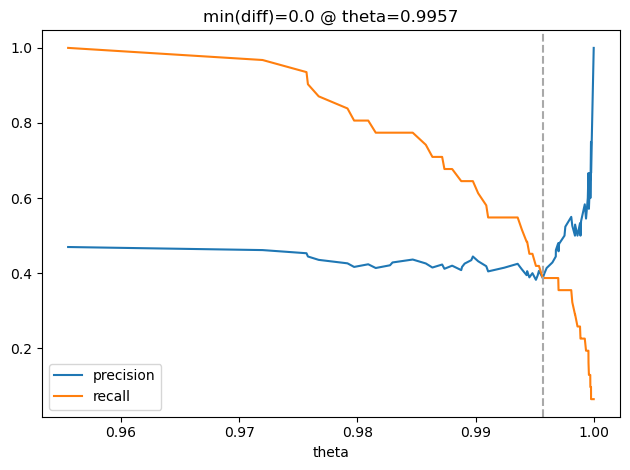

In [14]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

distances = 1 - np.array(calib_df['jaccard'])
relevances = calib_df['authorship']
precisions, recalls, thresholds = precision_recall_curve(relevances, distances, pos_label='S')
diffs = np.abs(precisions - recalls)
max_diff_idx = np.array(diffs).argmin()
max_diff = diffs[max_diff_idx]
max_diff_th = thresholds[max_diff_idx]
print(f'max(f1)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')

plt.plot(thresholds, precisions[:-1], label='precision')
plt.plot(thresholds, recalls[:-1], label='recall')
plt.axvline(max_diff_th, ls='--', c='darkgrey')
plt.gca().set_xlabel('theta')
plt.gca().legend()
plt.title(f'min(diff)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')
plt.tight_layout()

In [15]:
calib_thresh = 1 - max_diff_th
calib_thresh

0.004308458716213992

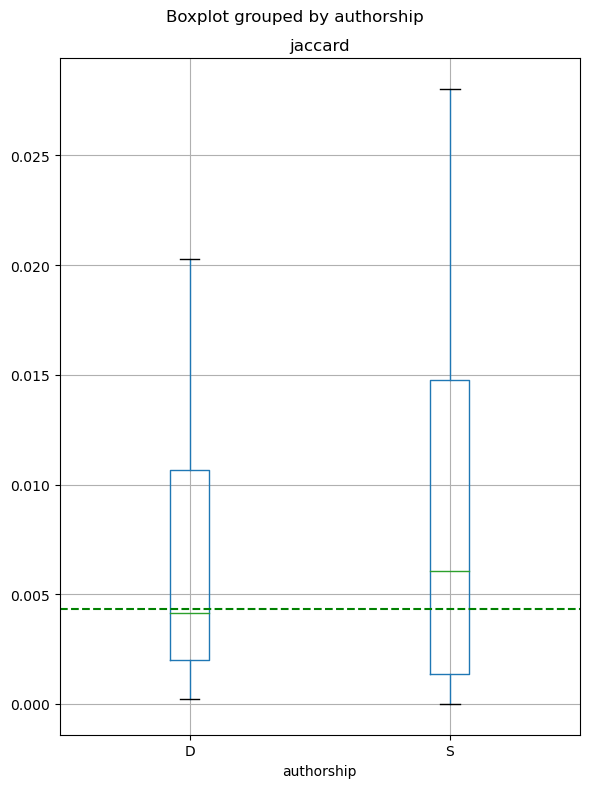

In [16]:
calib_df.boxplot('jaccard', 'authorship', figsize=(6, 8), showfliers=False)
plt.axhline(calib_thresh, c='green', ls='--')
plt.tight_layout();

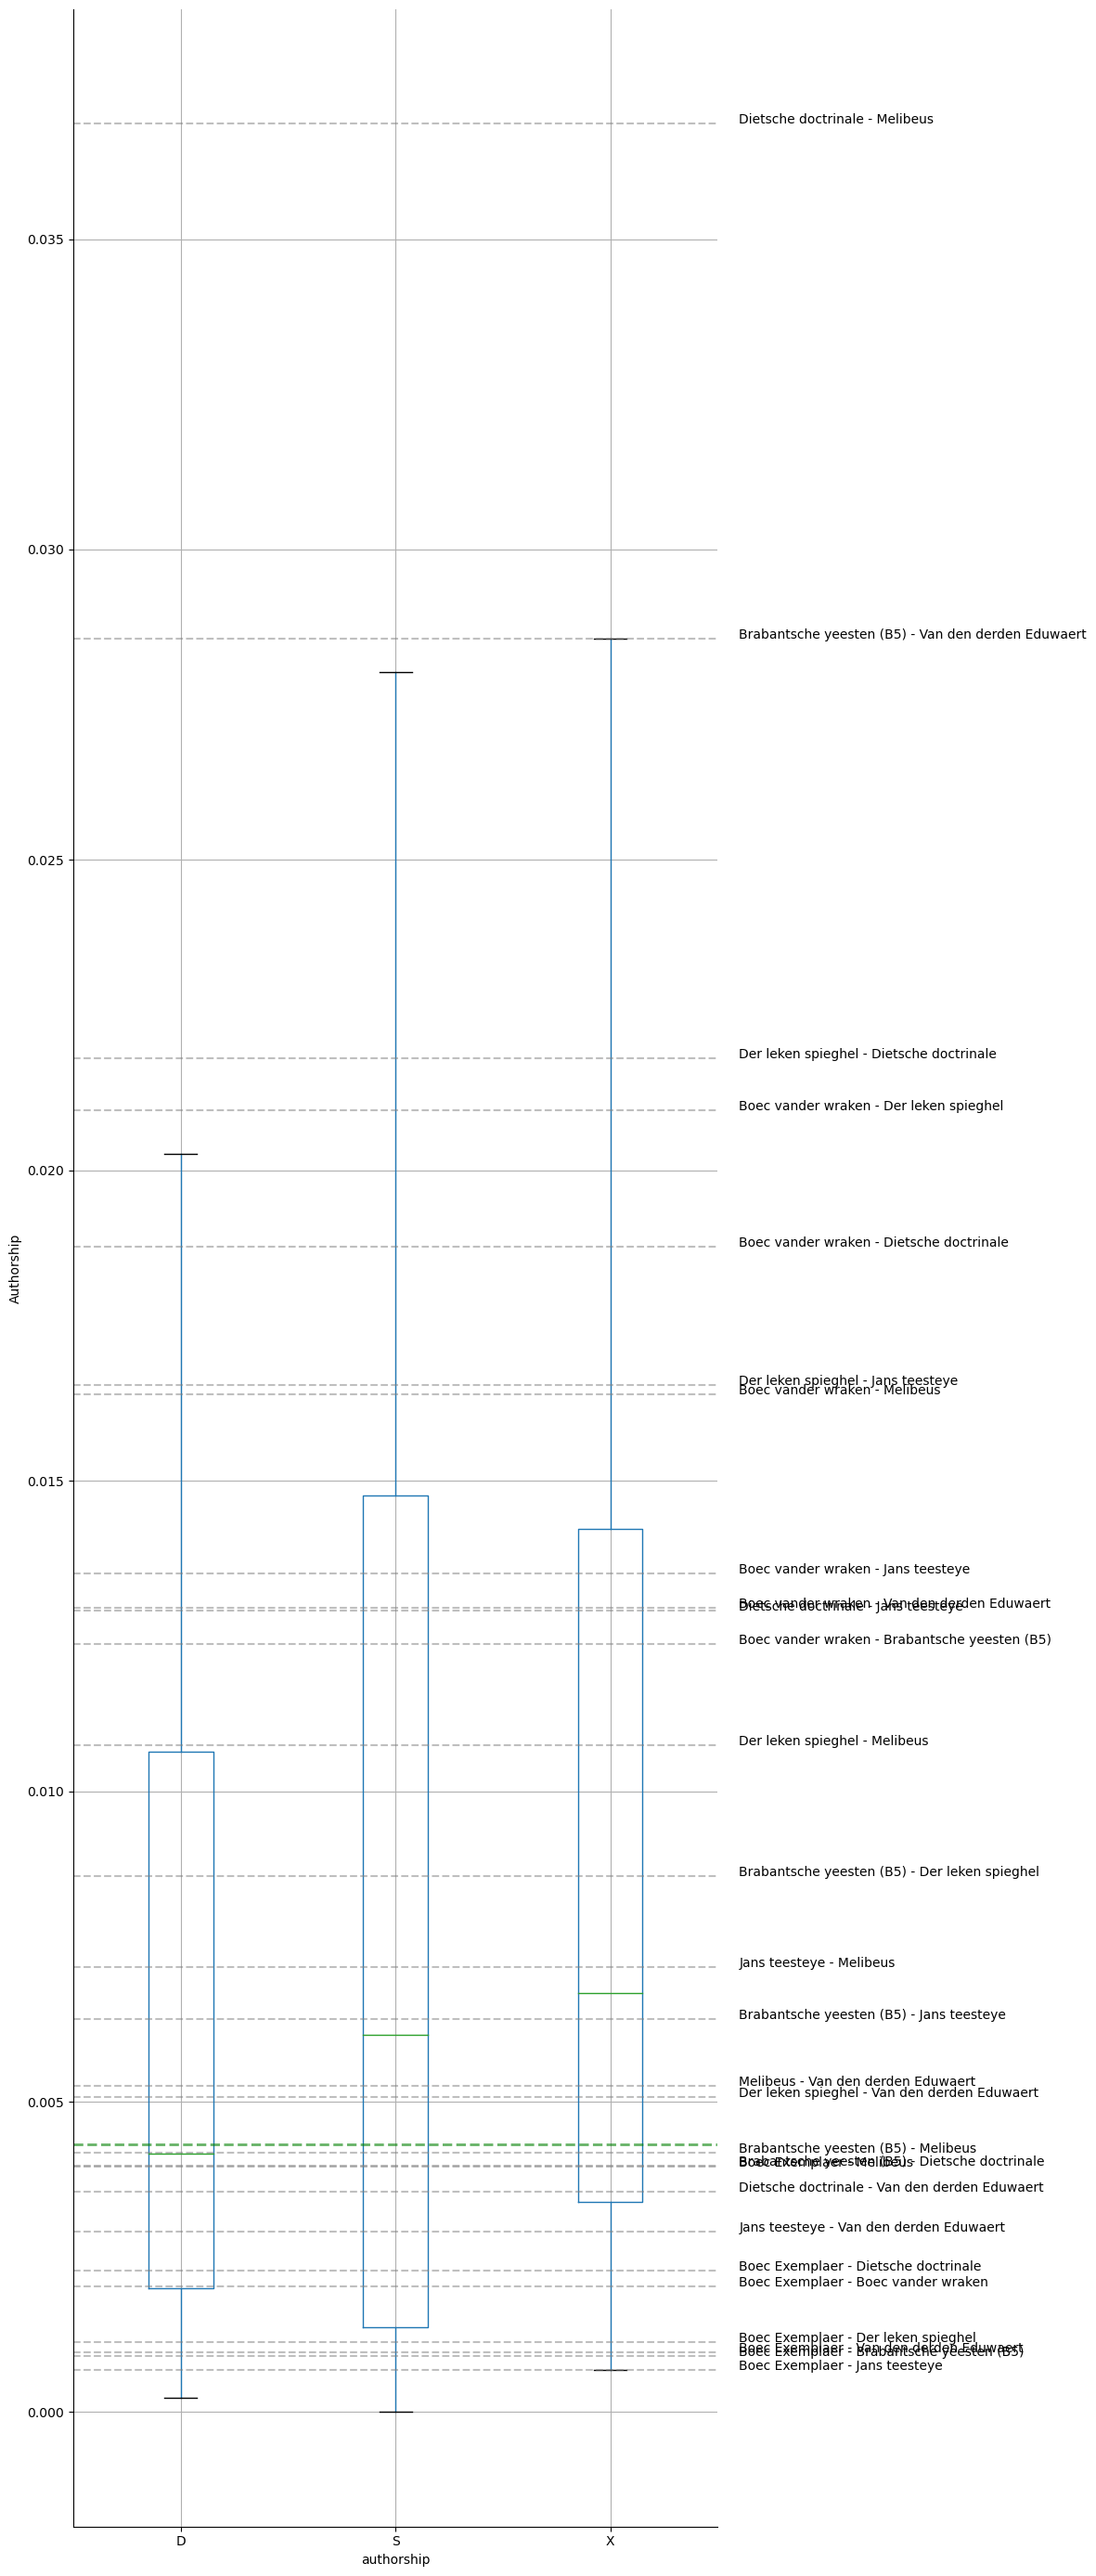

In [17]:
import seaborn as sb

distances = pd.concat([calib_df, trg_df])

distances.boxplot('jaccard', 'authorship', figsize=(12, 28), showfliers=False)
sb.despine()
plt.axhline(calib_thresh, c='green', linewidth=2, ls='--', alpha=.6)

for grouper, group in distances.groupby('authorship'):
    if grouper == 'X':
        for m, d in group.groupby(['t1', 't2'])['jaccard']:
            plt.gca().axhline(d.mean(), c='grey', ls='--', alpha=.5)
            plt.annotate(' - '.join(m), xy=[plt.gca().get_xlim()[1]+0.1, d.mean()],
                         annotation_clip=False)
            
plt.title('')
plt.ylabel('Jaccard Similarity')
plt.ylabel('Authorship')
plt.suptitle('')

plt.tight_layout();

## Sørensen–Dice

max(f1)=0.0 @ theta=0.9914


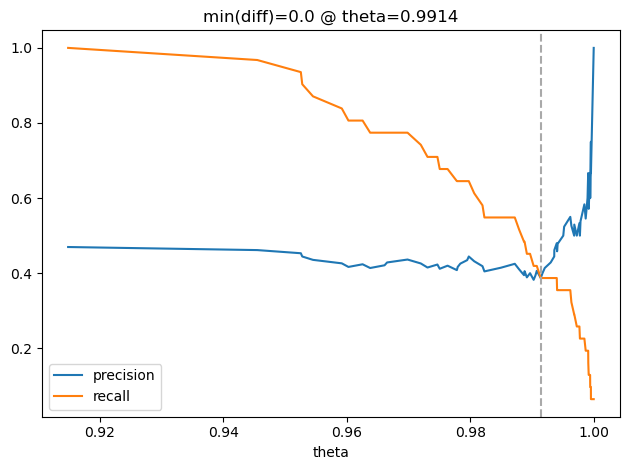

In [18]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

distances = 1 - np.array(calib_df['dice'])
relevances = calib_df['authorship']
precisions, recalls, thresholds = precision_recall_curve(relevances, distances, pos_label='S')
diffs = np.abs(precisions - recalls)
max_diff_idx = np.array(diffs).argmin()
max_diff = diffs[max_diff_idx]
max_diff_th = thresholds[max_diff_idx]
print(f'max(f1)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')

plt.plot(thresholds, precisions[:-1], label='precision')
plt.plot(thresholds, recalls[:-1], label='recall')
plt.axvline(max_diff_th, ls='--', c='darkgrey')
plt.gca().set_xlabel('theta')
plt.gca().legend()
plt.title(f'min(diff)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')
plt.tight_layout()

In [19]:
calib_thresh = 1 - max_diff_th
calib_thresh

0.008579951067466562

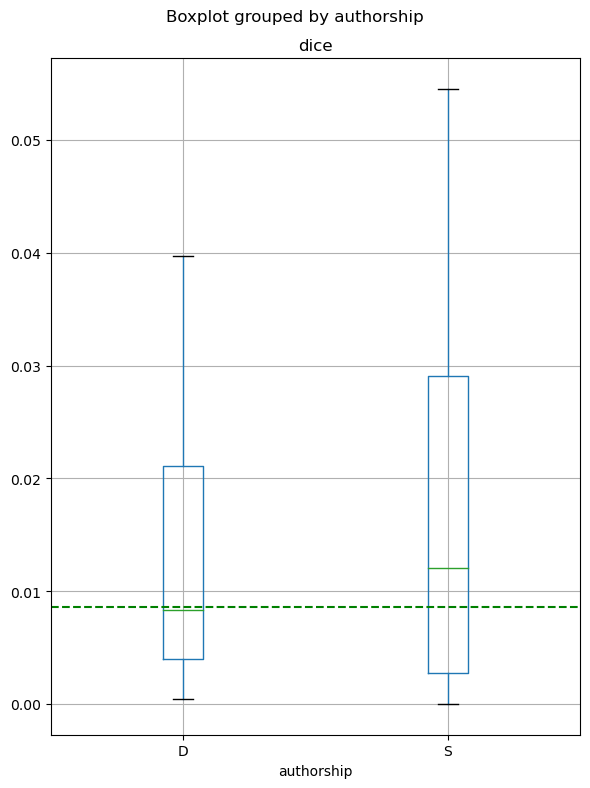

In [20]:
calib_df.boxplot('dice', 'authorship', figsize=(6, 8), showfliers=False)
plt.axhline(calib_thresh, c='green', ls='--')
plt.tight_layout();

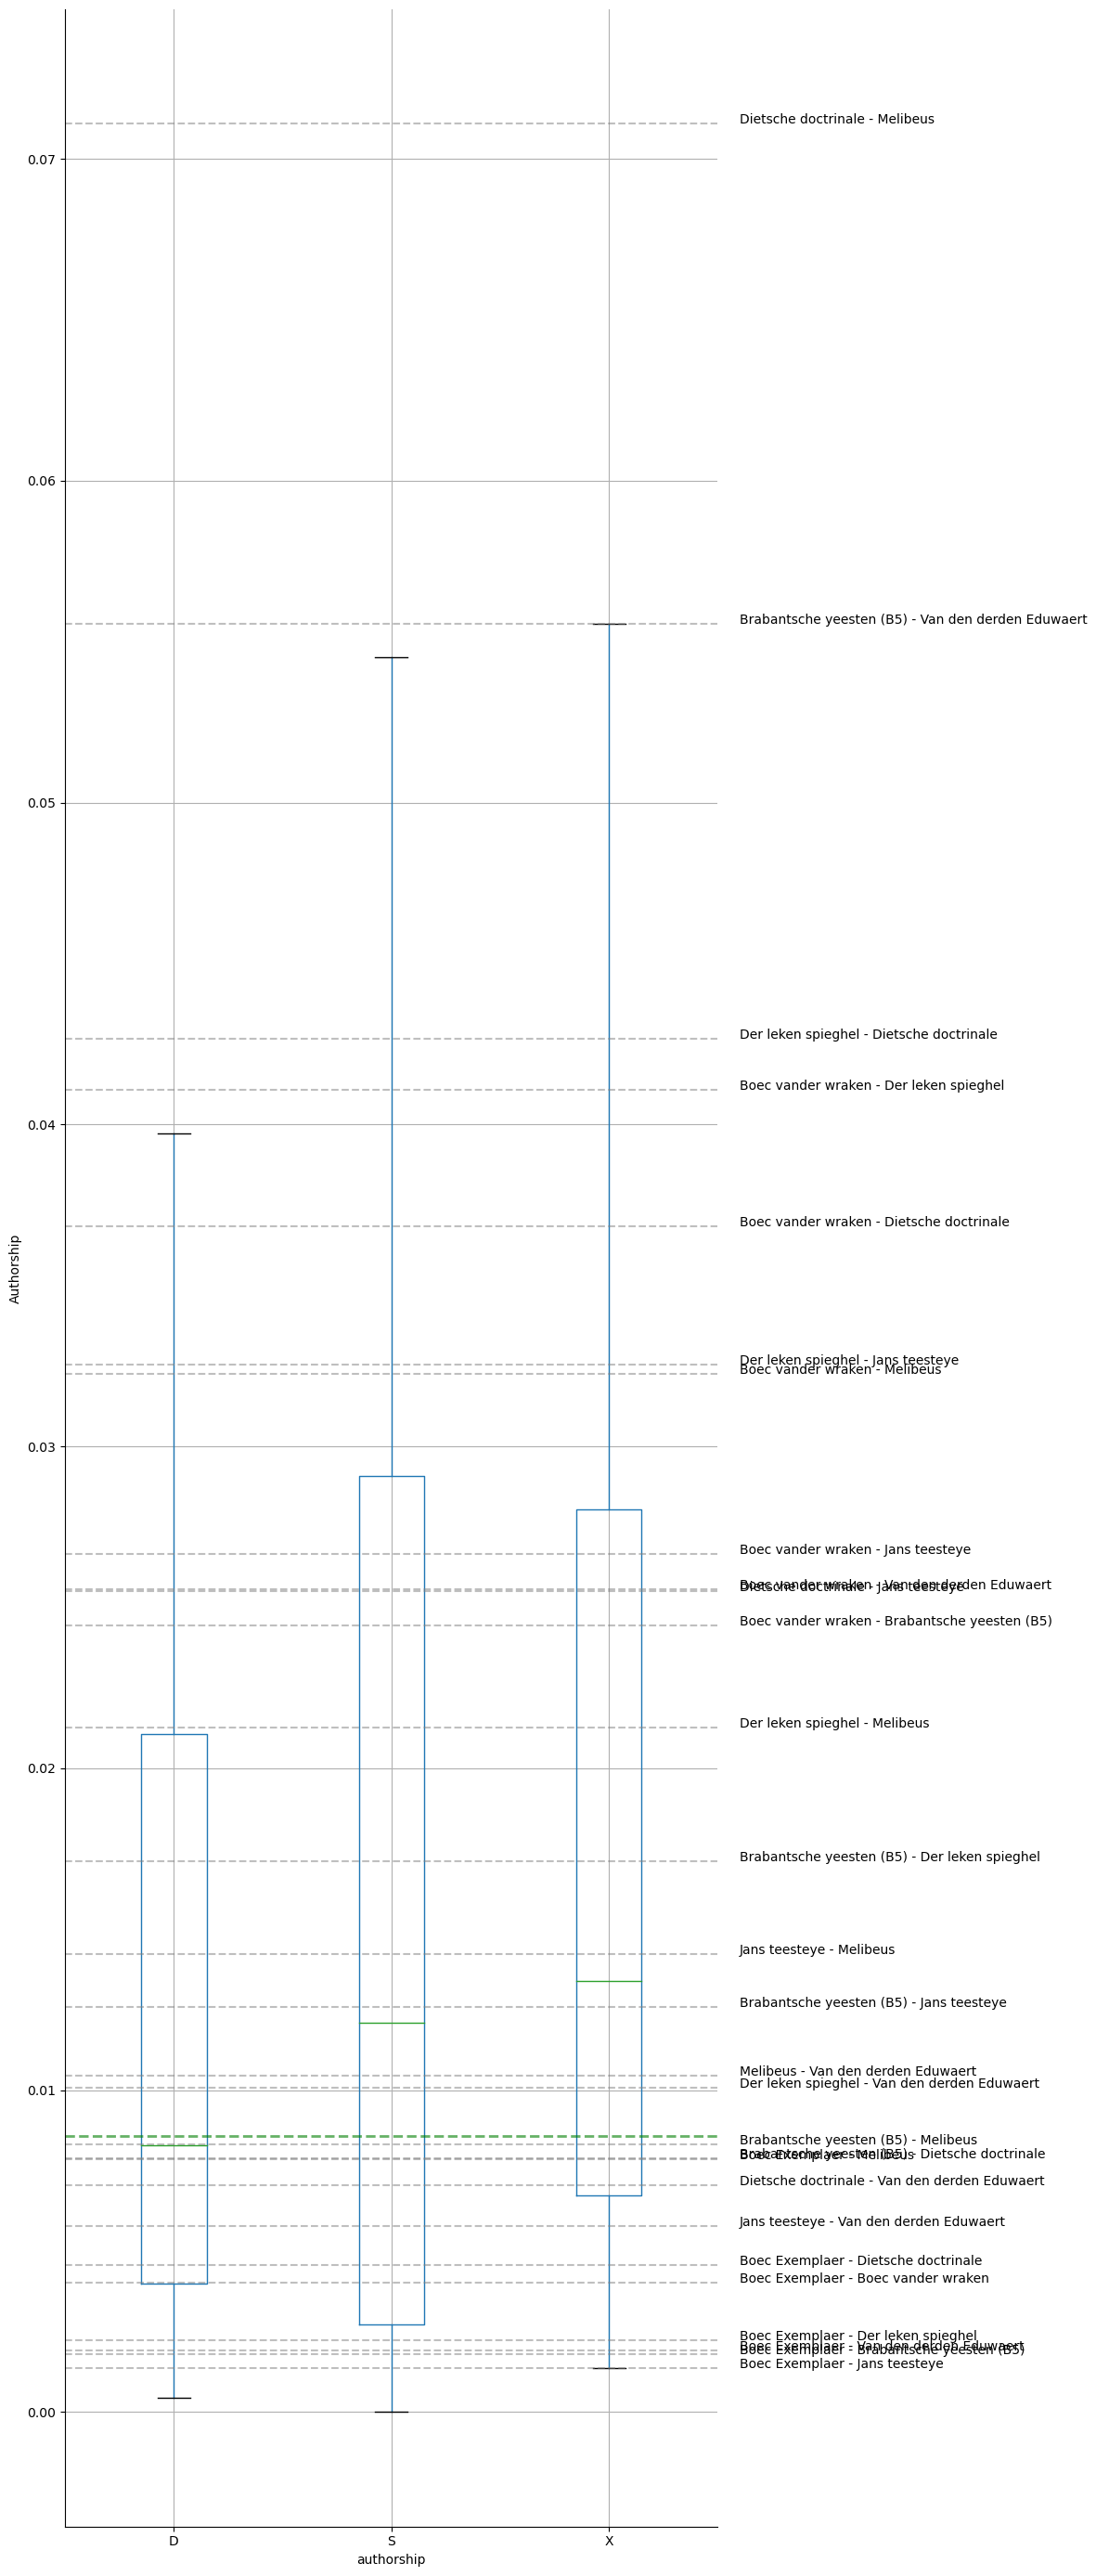

In [21]:
import seaborn as sb

distances = pd.concat([calib_df, trg_df])

distances.boxplot('dice', 'authorship', figsize=(12, 28), showfliers=False)
sb.despine()
plt.axhline(calib_thresh, c='green', linewidth=2, ls='--', alpha=.6)

for grouper, group in distances.groupby('authorship'):
    if grouper == 'X':
        for m, d in group.groupby(['t1', 't2'])['dice']:
            plt.gca().axhline(d.mean(), c='grey', ls='--', alpha=.5)
            plt.annotate(' - '.join(m), xy=[plt.gca().get_xlim()[1]+0.1, d.mean()],
                         annotation_clip=False)
            
plt.title('')
plt.ylabel('Sørensen–Dice index')
plt.ylabel('Authorship')
plt.suptitle('')

plt.tight_layout();

## Szymkiewicz–Simpson

max(f1)=0.0 @ theta=0.9728


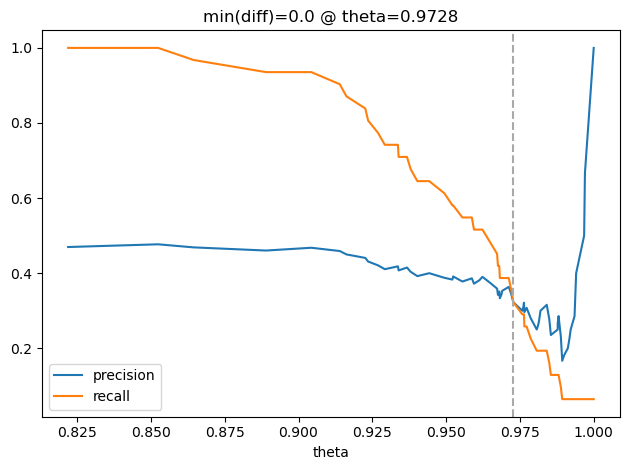

In [22]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

distances = 1 - np.array(calib_df['simpson'])
relevances = calib_df['authorship']
precisions, recalls, thresholds = precision_recall_curve(relevances, distances, pos_label='S')
diffs = np.abs(precisions - recalls)
max_diff_idx = np.array(diffs).argmin()
max_diff = diffs[max_diff_idx]
max_diff_th = thresholds[max_diff_idx]
print(f'max(f1)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')

plt.plot(thresholds, precisions[:-1], label='precision')
plt.plot(thresholds, recalls[:-1], label='recall')
plt.axvline(max_diff_th, ls='--', c='darkgrey')
plt.gca().set_xlabel('theta')
plt.gca().legend()
plt.title(f'min(diff)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')
plt.tight_layout()

In [23]:
calib_thresh = 1 - max_diff_th
calib_thresh

0.027229204069419533

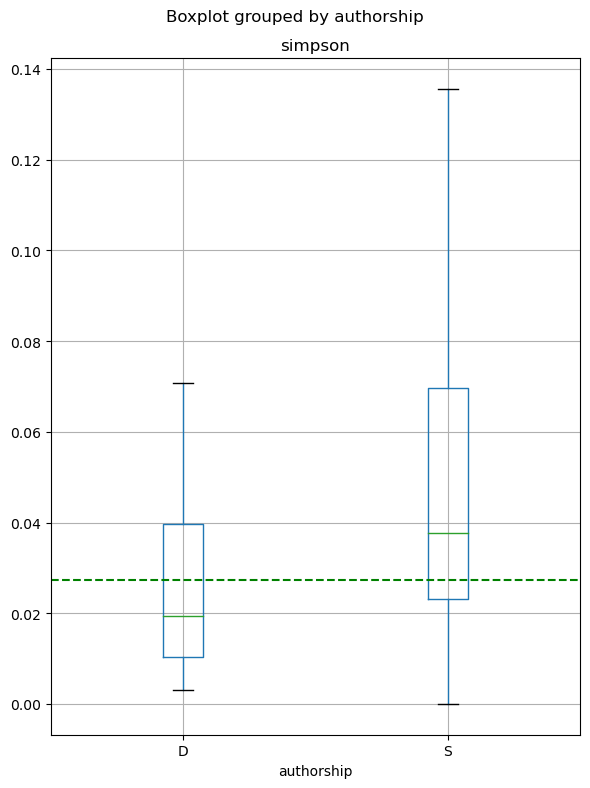

In [24]:
calib_df.boxplot('simpson', 'authorship', figsize=(6, 8), showfliers=False)
plt.axhline(calib_thresh, c='green', ls='--')
plt.tight_layout();

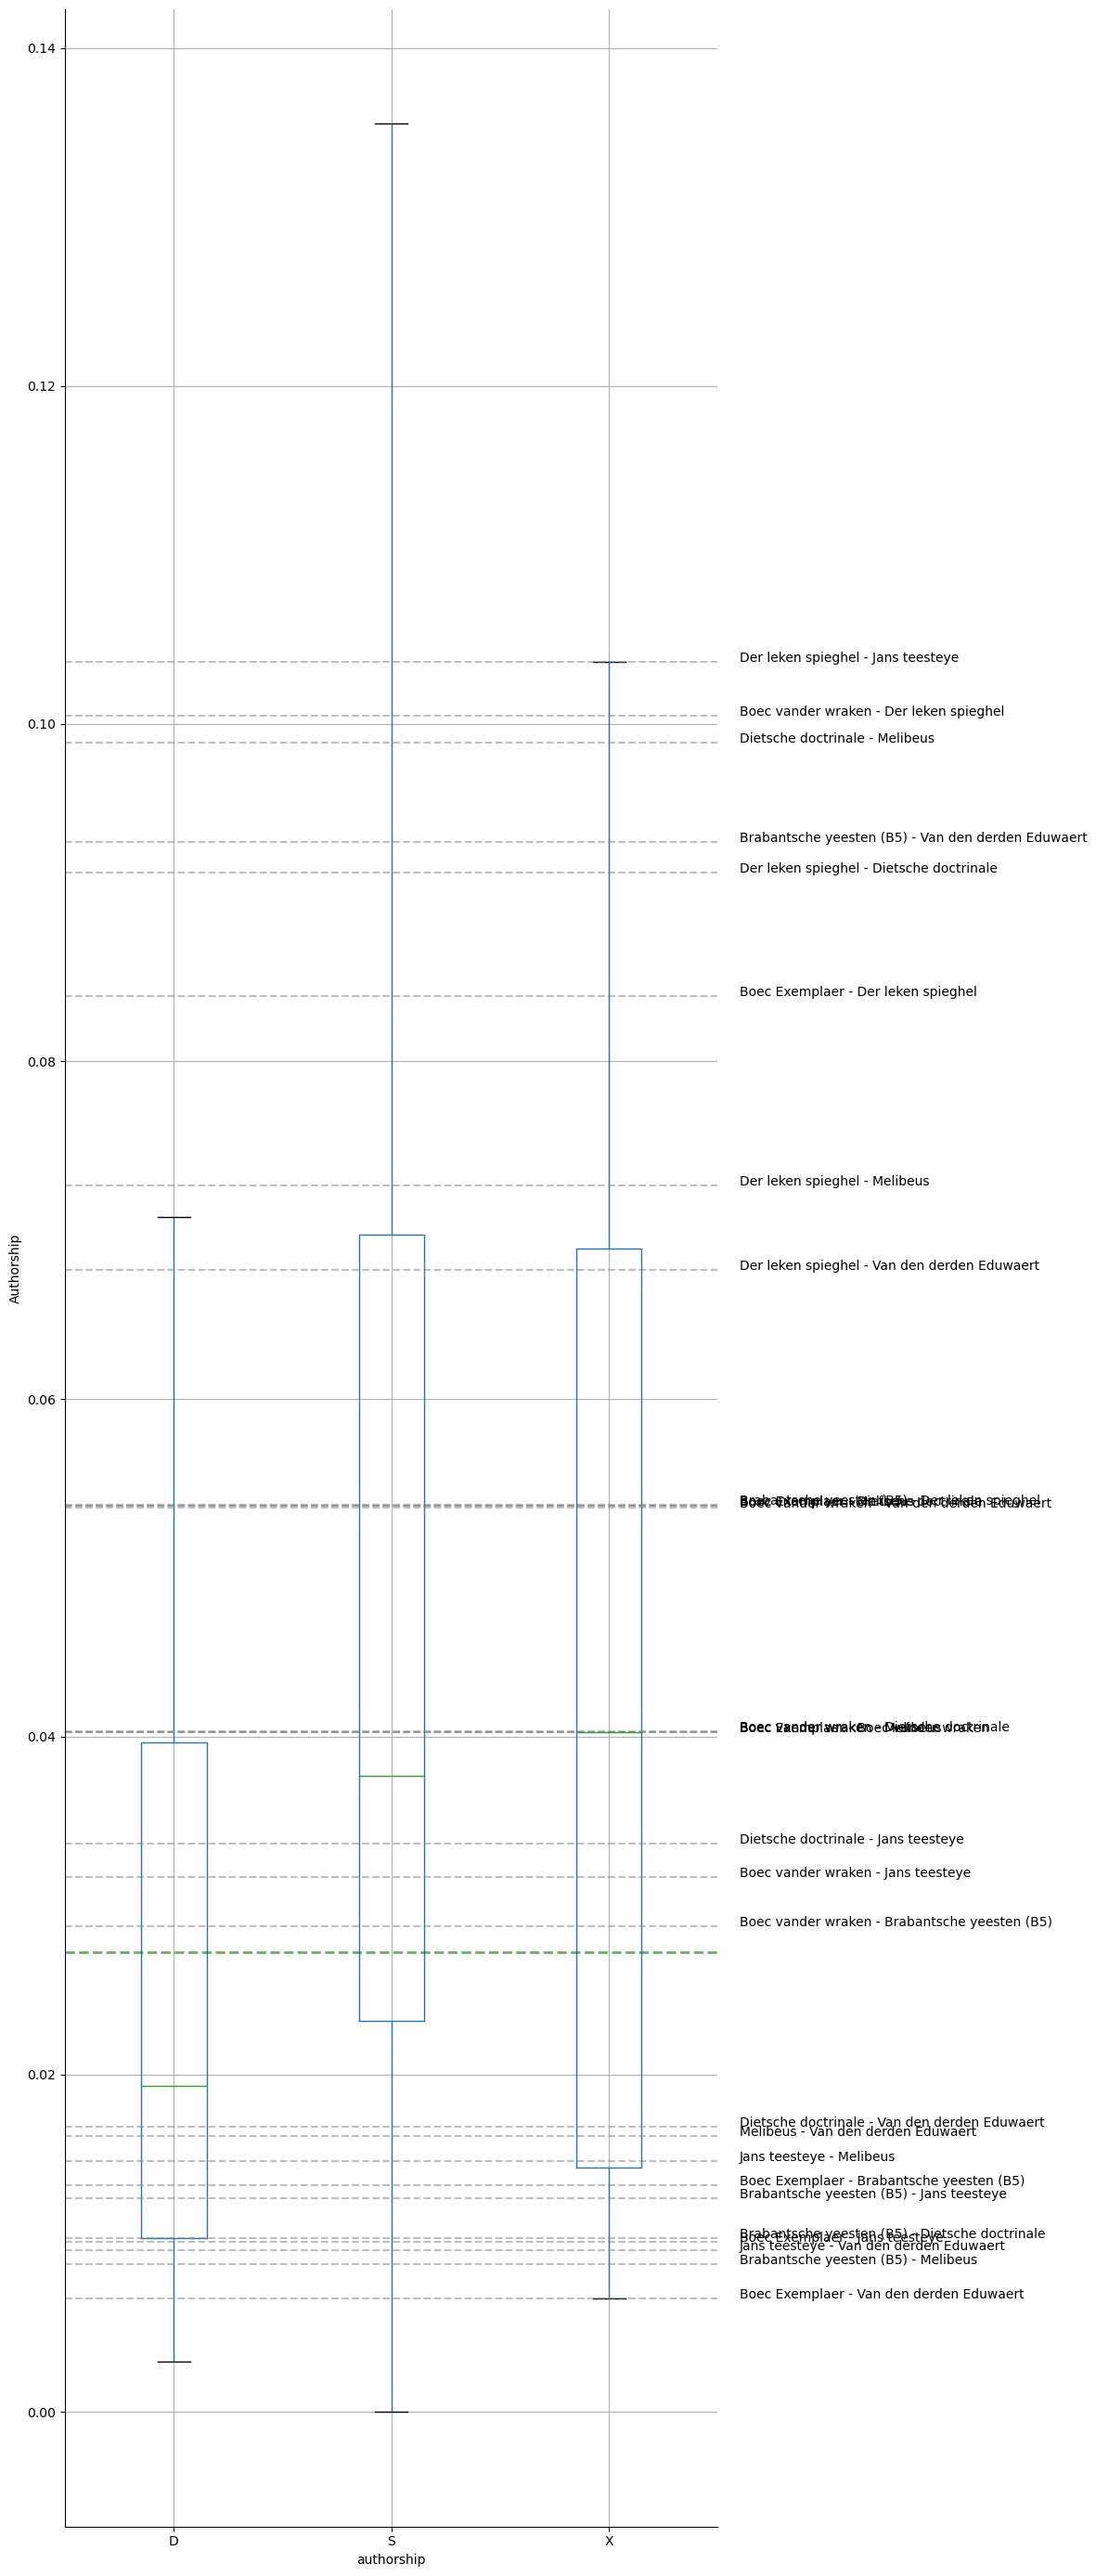

In [25]:
import seaborn as sb

distances = pd.concat([calib_df, trg_df])

distances.boxplot('simpson', 'authorship', figsize=(12, 28), showfliers=False)
sb.despine()
plt.axhline(calib_thresh, c='green', linewidth=2, ls='--', alpha=.6)

for grouper, group in distances.groupby('authorship'):
    if grouper == 'X':
        for m, d in group.groupby(['t1', 't2'])['simpson']:
            plt.gca().axhline(d.mean(), c='grey', ls='--', alpha=.5)
            plt.annotate(' - '.join(m), xy=[plt.gca().get_xlim()[1]+0.1, d.mean()],
                         annotation_clip=False)
            
plt.title('')
plt.ylabel('Szymkiewicz–Simpson index')
plt.ylabel('Authorship')
plt.suptitle('')

plt.tight_layout();

## Casy study
Code is relatively clean up until here

### Boec Exemplaer

In [26]:
BE = jaccard_df[(jaccard_df['t1'] == 'Boec Exemplaer') | (jaccard_df['t2'] == 'Boec Exemplaer')]
BE

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson
1652,Boec Exemplaer,Melibeus,16,NaN,NaN,Didactiek,Didactiek,298,3772,4054,0.003947,0.007862,298,0.053691
1614,Boec Exemplaer,Expositie vanden viere vingheren ende vanden dume,2,NaN,NaN,Didactiek,Didactiek,298,219,515,0.003883,0.007737,219,0.009132
1610,Boec Exemplaer,Dietsche doctrinale,16,NaN,NaN,Didactiek,Didactiek,298,6721,7003,0.002285,0.004559,298,0.053691
809,Barlaam en Josaphat,Boec Exemplaer,1,NaN,NaN,Ridder,Didactiek,178,298,475,0.002105,0.004202,178,0.005618
332,Anatomie van de mens,Boec Exemplaer,1,NaN,NaN,Didactiek,Didactiek,181,298,478,0.002092,0.004175,181,0.005525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1627,Boec Exemplaer,Godevaert metten baerde,0,NaN,NaN,Didactiek,Kruisvaart,298,63,361,0.000000,0.000000,63,0.000000
1628,Boec Exemplaer,Godevaerts kintshede,0,NaN,NaN,Didactiek,Kruisvaart,298,56,354,0.000000,0.000000,56,0.000000
1631,Boec Exemplaer,Gwidekijn van Sassen,0,NaN,NaN,Didactiek,Karel,298,200,498,0.000000,0.000000,200,0.000000
1431,Beginsel der oorlogen van Luyck,Boec Exemplaer,0,NaN,NaN,Historiografie,Didactiek,534,298,832,0.000000,0.000000,298,0.000000


In [27]:
BE.sort_values(by="jaccard", ascending=False).head(10)

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson
1652,Boec Exemplaer,Melibeus,16,NaN,NaN,Didactiek,Didactiek,298,3772,4054,0.003947,0.007862,298,0.053691
1614,Boec Exemplaer,Expositie vanden viere vingheren ende vanden dume,2,NaN,NaN,Didactiek,Didactiek,298,219,515,0.003883,0.007737,219,0.009132
1610,Boec Exemplaer,Dietsche doctrinale,16,NaN,NaN,Didactiek,Didactiek,298,6721,7003,0.002285,0.004559,298,0.053691
809,Barlaam en Josaphat,Boec Exemplaer,1,NaN,NaN,Ridder,Didactiek,178,298,475,0.002105,0.004202,178,0.005618
332,Anatomie van de mens,Boec Exemplaer,1,NaN,NaN,Didactiek,Didactiek,181,298,478,0.002092,0.004175,181,0.005525
1586,Boec Exemplaer,Boec vander wraken,12,NaN,Jan van Boendale,Didactiek,Didactiek,298,5654,5940,0.002020,0.004032,298,0.040268
1700,Boec Exemplaer,Sinte Lutgart,7,NaN,NaN,Didactiek,Heiligenleven,298,3659,3950,0.001772,0.003538,298,0.023490
1727,Boec Exemplaer,Van smeinscen lede,4,NaN,NaN,Didactiek,Didactiek,298,2029,2323,0.001722,0.003438,298,0.013423
1686,Boec Exemplaer,Roman van Caesar,2,NaN,NaN,Didactiek,Ridder,298,1018,1314,0.001522,0.003040,298,0.006711
1641,Boec Exemplaer,Korte kroniek van Brabant (korte versie 1),1,NaN,Jan van Boendale,Didactiek,Historiografie,298,374,671,0.001490,0.002976,298,0.003356


In [28]:
BE.sort_values(by="simpson", ascending=False).head(10)

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson
1603,Boec Exemplaer,Der leken spieghel,25,NaN,Jan van Boendale,Didactiek,Didactiek,298,22006,22279,0.001122,0.002242,298,0.083893
1679,Boec Exemplaer,Rijmbijbel,25,NaN,Jacob van Maerlant,Didactiek,Religie,298,35982,36255,0.000690,0.001378,298,0.083893
1705,Boec Exemplaer,Spiegel historiael (P1-P4),24,NaN,Jacob van Maerlant,Didactiek,Historiografie,298,88714,88988,0.000270,0.000539,298,0.080537
1652,Boec Exemplaer,Melibeus,16,NaN,NaN,Didactiek,Didactiek,298,3772,4054,0.003947,0.007862,298,0.053691
1610,Boec Exemplaer,Dietsche doctrinale,16,NaN,NaN,Didactiek,Didactiek,298,6721,7003,0.002285,0.004559,298,0.053691
1643,Boec Exemplaer,Lancelot,15,NaN,NaN,Didactiek,Arthur,298,37318,37601,0.000399,0.000798,298,0.050336
1586,Boec Exemplaer,Boec vander wraken,12,NaN,Jan van Boendale,Didactiek,Didactiek,298,5654,5940,0.002020,0.004032,298,0.040268
1706,Boec Exemplaer,Spiegel historiael (P2),12,NaN,Philip Utenbroeke,Didactiek,Historiografie,298,35007,35293,0.000340,0.000680,298,0.040268
1634,Boec Exemplaer,Historie van Troyen,11,NaN,Jacob van Maerlant,Didactiek,Ridder,298,37583,37870,0.000290,0.000581,298,0.036913
492,Arturs doet,Boec Exemplaer,9,NaN,NaN,Arthur,Didactiek,13025,298,13314,0.000676,0.001351,298,0.030201


In [29]:
BE.sort_values(by="dice", ascending=False).head(10)

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson
1652,Boec Exemplaer,Melibeus,16,NaN,NaN,Didactiek,Didactiek,298,3772,4054,0.003947,0.007862,298,0.053691
1614,Boec Exemplaer,Expositie vanden viere vingheren ende vanden dume,2,NaN,NaN,Didactiek,Didactiek,298,219,515,0.003883,0.007737,219,0.009132
1610,Boec Exemplaer,Dietsche doctrinale,16,NaN,NaN,Didactiek,Didactiek,298,6721,7003,0.002285,0.004559,298,0.053691
809,Barlaam en Josaphat,Boec Exemplaer,1,NaN,NaN,Ridder,Didactiek,178,298,475,0.002105,0.004202,178,0.005618
332,Anatomie van de mens,Boec Exemplaer,1,NaN,NaN,Didactiek,Didactiek,181,298,478,0.002092,0.004175,181,0.005525
1586,Boec Exemplaer,Boec vander wraken,12,NaN,Jan van Boendale,Didactiek,Didactiek,298,5654,5940,0.002020,0.004032,298,0.040268
1700,Boec Exemplaer,Sinte Lutgart,7,NaN,NaN,Didactiek,Heiligenleven,298,3659,3950,0.001772,0.003538,298,0.023490
1727,Boec Exemplaer,Van smeinscen lede,4,NaN,NaN,Didactiek,Didactiek,298,2029,2323,0.001722,0.003438,298,0.013423
1686,Boec Exemplaer,Roman van Caesar,2,NaN,NaN,Didactiek,Ridder,298,1018,1314,0.001522,0.003040,298,0.006711
1641,Boec Exemplaer,Korte kroniek van Brabant (korte versie 1),1,NaN,Jan van Boendale,Didactiek,Historiografie,298,374,671,0.001490,0.002976,298,0.003356


In [46]:
# Create a function to calculate directed jaccard based on Boec's position
def compute_directed_jaccard(row, t):
    if row['t1'] == t:
        return row['parallel_verses'] / row['verse_count_t1']
    elif row['t2'] == t:
        return row['parallel_verses'] / row['verse_count_t2']
    else:
        return None  # Shouldn't happen in this filtered DF

# Apply to the BE dataframe
BE['directed_jaccard'] = BE.apply(compute_directed_jaccard, t='Boec Exemplaer', axis=1)
BE.sort_values(by="directed_jaccard", ascending=False).head(20)

/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/3373354946.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BE['directed_jaccard'] = BE.apply(compute_directed_jaccard, t='Boec Exemplaer', axis=1)


,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson,directed_jaccard,other_title,group,other_author,other_subgenre
1679,Boec Exemplaer,Rijmbijbel,25,NaN,Jacob van Maerlant,Didactiek,Religie,298,35982,36255,0.000690,0.001378,298,0.083893,0.083893,Rijmbijbel,None,Jacob van Maerlant,Religie
1603,Boec Exemplaer,Der leken spieghel,25,NaN,Jan van Boendale,Didactiek,Didactiek,298,22006,22279,0.001122,0.002242,298,0.083893,0.083893,Der leken spieghel,Target (Specific Titles),Jan van Boendale,Didactiek
1705,Boec Exemplaer,Spiegel historiael (P1-P4),24,NaN,Jacob van Maerlant,Didactiek,Historiografie,298,88714,88988,0.000270,0.000539,298,0.080537,0.080537,Spiegel historiael (P1-P4),Control (Didactiek or Historiografie),Jacob van Maerlant,Historiografie
1652,Boec Exemplaer,Melibeus,16,NaN,NaN,Didactiek,Didactiek,298,3772,4054,0.003947,0.007862,298,0.053691,0.053691,Melibeus,Target (Specific Titles),NaN,Didactiek
1610,Boec Exemplaer,Dietsche doctrinale,16,NaN,NaN,Didactiek,Didactiek,298,6721,7003,0.002285,0.004559,298,0.053691,0.053691,Dietsche doctrinale,Target (Specific Titles),NaN,Didactiek
1643,Boec Exemplaer,Lancelot,15,NaN,NaN,Didactiek,Arthur,298,37318,37601,0.000399,0.000798,298,0.050336,0.050336,Lancelot,None,NaN,Arthur
1586,Boec Exemplaer,Boec vander wraken,12,NaN,Jan van Boendale,Didactiek,Didactiek,298,5654,5940,0.002020,0.004032,298,0.040268,0.040268,Boec vander wraken,Target (Specific Titles),Jan van Boendale,Didactiek
1706,Boec Exemplaer,Spiegel historiael (P2),12,NaN,Philip Utenbroeke,Didactiek,Historiografie,298,35007,35293,0.000340,0.000680,298,0.040268,0.040268,Spiegel historiael (P2),Control (Didactiek or Historiografie),Philip Utenbroeke,Historiografie
1634,Boec Exemplaer,Historie van Troyen,11,NaN,Jacob van Maerlant,Didactiek,Ridder,298,37583,37870,0.000290,0.000581,298,0.036913,0.036913,Historie van Troyen,None,Jacob van Maerlant,Ridder
1709,Boec Exemplaer,Spieghel der menscheliker behoudenesse,9,NaN,NaN,Didactiek,Didactiek,298,14487,14776,0.000609,0.001217,298,0.030201,0.030201,Spieghel der menscheliker behoudenesse,Control (Didactiek or Historiografie),NaN,Didactiek


/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/2782818495.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BE['other_title'] = BE.apply(get_other_title, axis=1)
/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/2782818495.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BE['group'] = BE['other_title'].apply(lambda x: 'Target Set' if x in target_titles else 'Control Set')


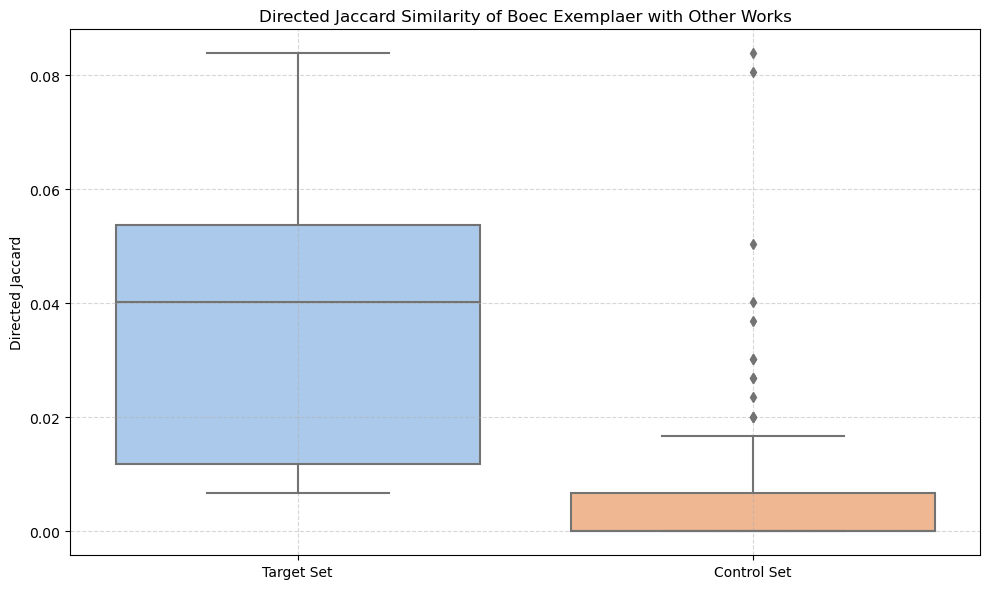

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your list of target titles
target_titles = [
    'Brabantsche yeesten (B5)',
    'Der leken spieghel',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Boec Exemplaer',
    'Dietsche doctrinale',
    'Boec vander wraken'
]

# Get all combinations where Boec Exemplaer is in t1 or t2
def get_other_title(row):
    return row['t2'] if row['t1'] == 'Boec Exemplaer' else row['t1']

# Apply to get the "other" title in each pairing
BE['other_title'] = BE.apply(get_other_title, axis=1)

# Create two groups based on whether the other title is in target_titles
BE['group'] = BE['other_title'].apply(lambda x: 'Target Set' if x in target_titles else 'Control Set')

# Set up the plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='group', y='directed_jaccard', data=BE, palette='pastel')

# Improve plot labels
plt.title('Directed Jaccard Similarity of Boec Exemplaer with Other Works')
plt.ylabel('Directed Jaccard')
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [37]:
BE

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson,directed_jaccard,other_title,group,other_author
1652,Boec Exemplaer,Melibeus,16,NaN,NaN,Didactiek,Didactiek,298,3772,4054,0.003947,0.007862,298,0.053691,0.053691,Melibeus,Target Set,NaN
1614,Boec Exemplaer,Expositie vanden viere vingheren ende vanden dume,2,NaN,NaN,Didactiek,Didactiek,298,219,515,0.003883,0.007737,219,0.009132,0.006711,Expositie vanden viere vingheren ende vanden dume,Control Set,NaN
1610,Boec Exemplaer,Dietsche doctrinale,16,NaN,NaN,Didactiek,Didactiek,298,6721,7003,0.002285,0.004559,298,0.053691,0.053691,Dietsche doctrinale,Target Set,NaN
809,Barlaam en Josaphat,Boec Exemplaer,1,NaN,NaN,Ridder,Didactiek,178,298,475,0.002105,0.004202,178,0.005618,0.003356,Barlaam en Josaphat,Control Set,NaN
332,Anatomie van de mens,Boec Exemplaer,1,NaN,NaN,Didactiek,Didactiek,181,298,478,0.002092,0.004175,181,0.005525,0.003356,Anatomie van de mens,Control Set,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1627,Boec Exemplaer,Godevaert metten baerde,0,NaN,NaN,Didactiek,Kruisvaart,298,63,361,0.000000,0.000000,63,0.000000,0.000000,Godevaert metten baerde,Control Set,NaN
1628,Boec Exemplaer,Godevaerts kintshede,0,NaN,NaN,Didactiek,Kruisvaart,298,56,354,0.000000,0.000000,56,0.000000,0.000000,Godevaerts kintshede,Control Set,NaN
1631,Boec Exemplaer,Gwidekijn van Sassen,0,NaN,NaN,Didactiek,Karel,298,200,498,0.000000,0.000000,200,0.000000,0.000000,Gwidekijn van Sassen,Control Set,NaN
1431,Beginsel der oorlogen van Luyck,Boec Exemplaer,0,NaN,NaN,Historiografie,Didactiek,534,298,832,0.000000,0.000000,298,0.000000,0.000000,Beginsel der oorlogen van Luyck,Control Set,NaN


/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/1960944640.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BE[['other_title', 'other_author']] = BE.apply(lambda row: pd.Series(get_other_info(row)), axis=1)
/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/1960944640.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BE['group'] = BE.apply(assign_group, axis=1)


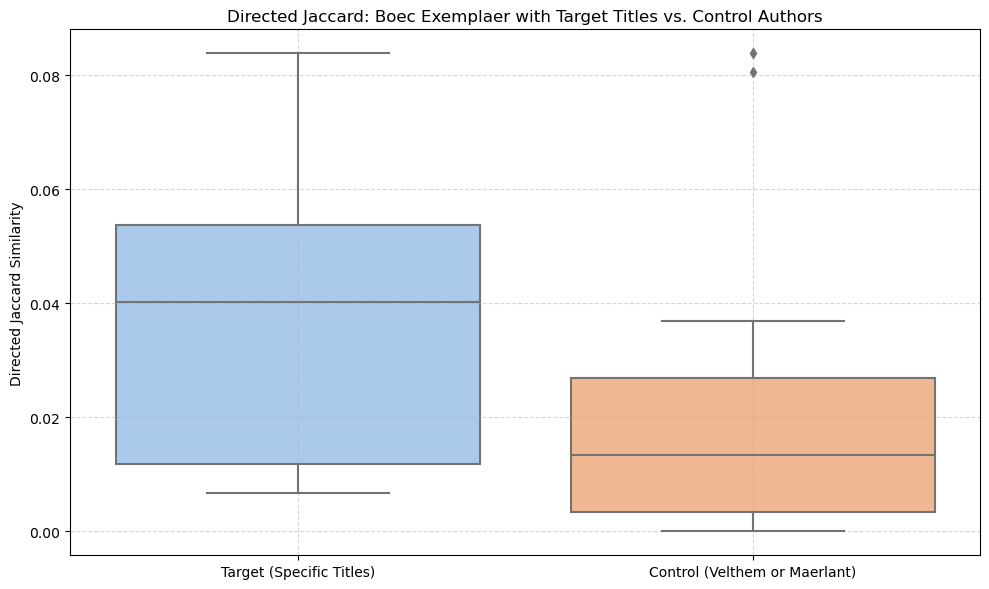

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of specific target titles
target_titles = [
    'Brabantsche yeesten (B5)',
    'Der leken spieghel',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Boec Exemplaer',
    'Dietsche doctrinale',
    'Boec vander wraken'
]

# Control authors
control_authors = ['Lodewijk van Velthem', 'Jacob van Maerlant']

# Function to extract other title and other author
def get_other_info(row):
    if row['t1'] == 'Boec Exemplaer':
        return row['t2'], row['author_t2']
    elif row['t2'] == 'Boec Exemplaer':
        return row['t1'], row['author_t1']
    else:
        return None, None  # fallback

# Apply and expand into new columns
BE[['other_title', 'other_author']] = BE.apply(lambda row: pd.Series(get_other_info(row)), axis=1)

# Define grouping: Target vs Control
def assign_group(row):
    if row['other_title'] in target_titles:
        return 'Target (Specific Titles)'
    elif row['other_author'] in control_authors:
        return 'Control (Velthem or Maerlant)'
    else:
        return None  # exclude all others

# Apply group assignment
BE['group'] = BE.apply(assign_group, axis=1)

# Drop rows not in either group
filtered_BE = BE[BE['group'].notnull()]

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='group', y='directed_jaccard', data=filtered_BE, palette='pastel')

# Improve plot aesthetics
plt.title('Directed Jaccard: Boec Exemplaer with Target Titles vs. Control Authors')
plt.ylabel('Directed Jaccard Similarity')
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/465376597.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BE[['other_title', 'other_subgenre']] = BE.apply(lambda row: pd.Series(get_other_info(row)), axis=1)
/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/465376597.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BE[['other_title', 'other_subgenre']] = BE.apply(lambda row: pd.Series(get_other_info(row)), axis=1)
/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipyke

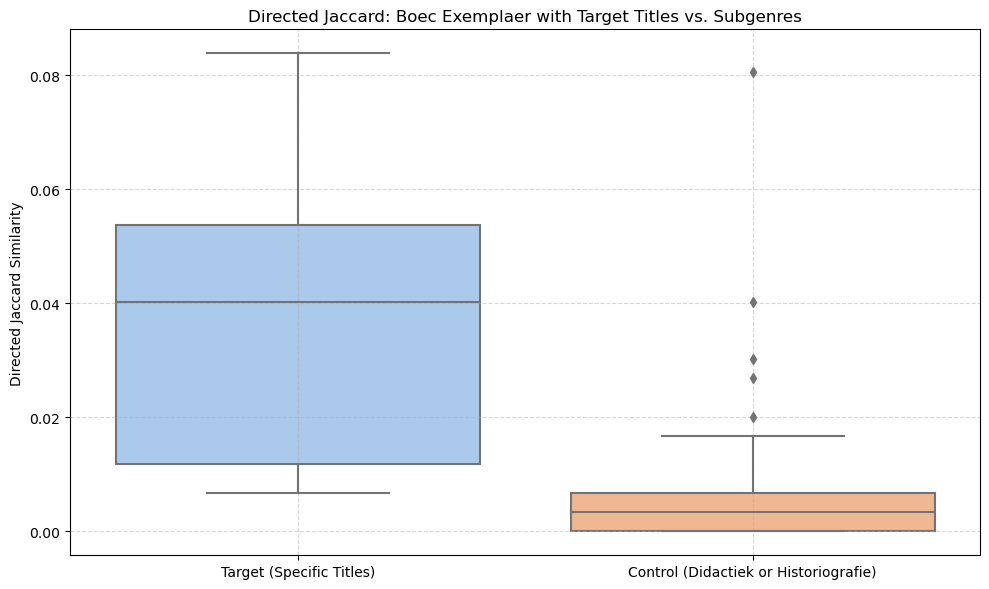

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define your target titles
target_titles = [
    'Brabantsche yeesten (B5)',
    'Der leken spieghel',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Boec Exemplaer',
    'Dietsche doctrinale',
    'Boec vander wraken'
]

# Define target subgenres for control
control_subgenres = ['Didactiek', 'Historiografie']

# Function to get the other title and subgenre
def get_other_info(row):
    if row['t1'] == 'Boec Exemplaer':
        return row['t2'], row['subgenre_t2']
    elif row['t2'] == 'Boec Exemplaer':
        return row['t1'], row['subgenre_t1']
    else:
        return None, None  # shouldn't occur in this dataset

# Apply function to create new columns
BE[['other_title', 'other_subgenre']] = BE.apply(lambda row: pd.Series(get_other_info(row)), axis=1)

# Assign group based on title list and subgenre
def assign_group(row):
    if row['other_title'] in target_titles:
        return 'Target (Specific Titles)'
    elif row['other_subgenre'] in control_subgenres:
        return 'Control (Didactiek or Historiografie)'
    else:
        return None  # exclude other pairings

BE['group'] = BE.apply(assign_group, axis=1)

# Filter only rows in target or control group
filtered_BE = BE[BE['group'].notnull()]

# Plotting
plt.figure(figsize=(10, 6))
sns.boxplot(x='group', y='directed_jaccard', data=filtered_BE, palette='pastel')

# Enhance appearance
plt.title('Directed Jaccard: Boec Exemplaer with Target Titles vs. Subgenres')
plt.ylabel('Directed Jaccard Similarity')
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [48]:
LS = jaccard_df[(jaccard_df['t1'] == 'Der leken spieghel') | (jaccard_df['t2'] == 'Der leken spieghel')]

LS['directed_jaccard'] = LS.apply(compute_directed_jaccard, t='Der leken spieghel', axis=1)
LS.sort_values(by="directed_jaccard", ascending=False).head(20)

/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/823116845.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LS['directed_jaccard'] = LS.apply(compute_directed_jaccard, t='Der leken spieghel', axis=1)


,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,dice,min_verses,simpson,directed_jaccard
4422,Der leken spieghel,Spiegel historiael (P1-P4),2357,Jan van Boendale,Jacob van Maerlant,Didactiek,Historiografie,22006,88714,108363,0.021751,0.042576,22006,0.107107,0.107107
4396,Der leken spieghel,Rijmbijbel,1410,Jan van Boendale,Jacob van Maerlant,Didactiek,Religie,22006,35982,56578,0.024921,0.048631,22006,0.064073,0.064073
4423,Der leken spieghel,Spiegel historiael (P2),1110,Jan van Boendale,Philip Utenbroeke,Didactiek,Historiografie,22006,35007,55903,0.019856,0.038938,22006,0.050441,0.050441
4360,Der leken spieghel,Lancelot,749,Jan van Boendale,NaN,Didactiek,Arthur,22006,37318,58575,0.012787,0.025251,22006,0.034036,0.034036
4351,Der leken spieghel,Historie van Troyen,663,Jan van Boendale,Jacob van Maerlant,Didactiek,Ridder,22006,37583,58926,0.011251,0.022252,22006,0.030128,0.030128
4327,Der leken spieghel,Dietsche doctrinale,613,Jan van Boendale,NaN,Didactiek,Didactiek,22006,6721,28114,0.021804,0.042678,6721,0.091207,0.027856
4426,Der leken spieghel,Spieghel der menscheliker behoudenesse,583,Jan van Boendale,NaN,Didactiek,Didactiek,22006,14487,35910,0.016235,0.031951,14487,0.040243,0.026493
1906,Boec vander wraken,Der leken spieghel,568,Jan van Boendale,Jan van Boendale,Didactiek,Didactiek,5654,22006,27092,0.020966,0.041070,5654,0.100460,0.025811
4425,Der leken spieghel,Spiegel historiael (P5),556,Jan van Boendale,Lodewijk van Velthem,Didactiek,Historiografie,22006,19342,40792,0.013630,0.026894,19342,0.028746,0.025266
4364,Der leken spieghel,Limborch,547,Jan van Boendale,NaN,Didactiek,Ridder,22006,21848,43307,0.012631,0.024946,21848,0.025037,0.024857


/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/2211451268.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LS['other_title'] = LS.apply(get_other_title, axis=1)
/var/folders/qv/jgq1ttws58g43xdmt2gthgth0000gn/T/ipykernel_18216/2211451268.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LS['group'] = LS['other_title'].apply(lambda x: 'Target Set' if x in target_titles else 'Control Set')


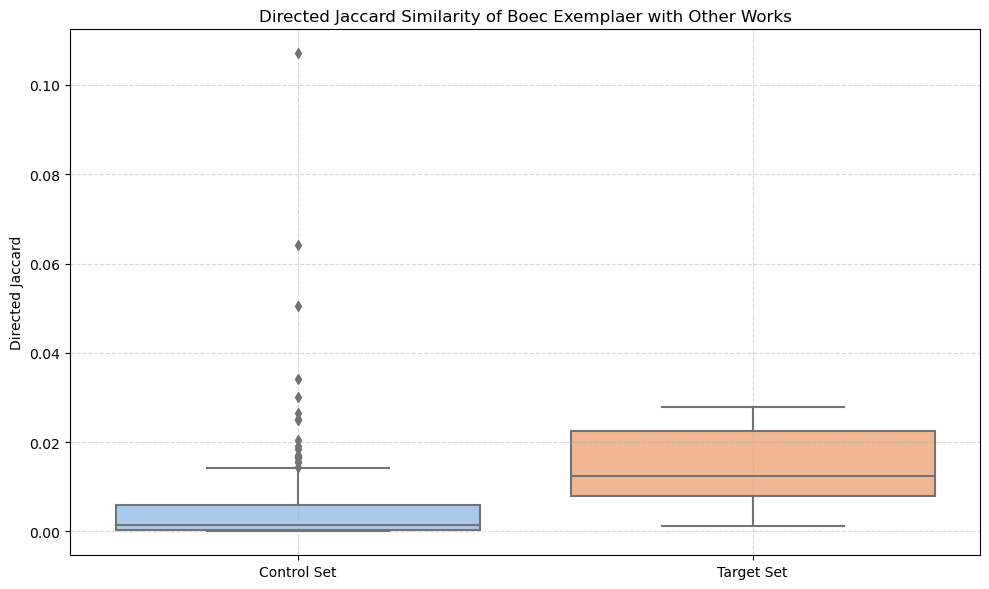

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your list of target titles
target_titles = [
    'Brabantsche yeesten (B5)',
    'Boec Exemplaer',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Boec Exemplaer',
    'Dietsche doctrinale',
    'Boec vander wraken'
]

# Get all combinations where Boec Exemplaer is in t1 or t2
def get_other_title(row):
    return row['t2'] if row['t1'] == 'Der leken spieghel' else row['t1']

# Apply to get the "other" title in each pairing
LS['other_title'] = LS.apply(get_other_title, axis=1)

# Create two groups based on whether the other title is in target_titles
LS['group'] = LS['other_title'].apply(lambda x: 'Target Set' if x in target_titles else 'Control Set')

# Set up the plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='group', y='directed_jaccard', data=LS, palette='pastel')

# Improve plot labels
plt.title('Directed Jaccard Similarity of Boec Exemplaer with Other Works')
plt.ylabel('Directed Jaccard')
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()